In [13]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
from torchdiffeq import odeint
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import os
import ssl
import joblib

## train

In [ ]:
ssl._create_default_https_context = ssl._create_unverified_context

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
def load_and_preprocess_data(file_path):
    df = pd.read_csv(file_path)

    selected_columns = ['Flow Duration', 'Total Fwd Packets',
        'Total Backward Packets', 'Fwd Packets Length Total',
        'Bwd Packets Length Total', 'Fwd Packet Length Max',
        'Fwd Packet Length Min', 'Fwd Packet Length Mean',
        'Fwd Packet Length Std', 'Bwd Packet Length Max',
        'Bwd Packet Length Min', 'Bwd Packet Length Mean',
        'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
        'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
        'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
        'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
        'Bwd IAT Max', 'Bwd IAT Min',  'Fwd Header Length',
        'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
        'Packet Length Min', 'Packet Length Max', 'Packet Length Mean',
        'Packet Length Std', 'Packet Length Variance', 
        'Down/Up Ratio',
        'Avg Packet Size', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size',
        'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate',
            'Subflow Fwd Bytes', 'Subflow Bwd Packets',
        'Subflow Bwd Bytes', 'Init Fwd Win Bytes', 'Init Bwd Win Bytes',
        'Fwd Act Data Packets', 'Fwd Seg Size Min', 'Active Mean', 'Active Std',
        'Active Max', 'Active Min', 'Label']

    df = df[selected_columns]
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.fillna(0, inplace=True)
    
    print("\nThông tin dữ liệu:")
    print(df.info())
    print("\n5 dòng đầu:")
    print(df.head())
    
    X = df.drop(columns=['Label']).values 
    y = df['Label'].values
    
    if isinstance(y[0], str):
        le = LabelEncoder()
        y = le.fit_transform(y)
        print("\nCác lớp nhãn đã mã hóa:", le.classes_)
    
    scaler = StandardScaler()
    X = scaler.fit_transform(X)
    
    return X, y

In [ ]:
file_path = 'csv/cicddos_2019_4_labels.csv'  # Thay bằng đường dẫn thực tế
X, y = load_and_preprocess_data(file_path)

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.1, random_state=42)
X_valid, X_test, y_valid, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Train: {X_train.shape}, {y_train.shape}")
print(f"Valid: {X_valid.shape}, {y_valid.shape}")
print(f"Test: {X_test.shape}, {y_test.shape}")


Thông tin dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 57 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Flow Duration             20000 non-null  int64  
 1   Total Fwd Packets         20000 non-null  int64  
 2   Total Backward Packets    20000 non-null  int64  
 3   Fwd Packets Length Total  20000 non-null  float64
 4   Bwd Packets Length Total  20000 non-null  float64
 5   Fwd Packet Length Max     20000 non-null  float64
 6   Fwd Packet Length Min     20000 non-null  float64
 7   Fwd Packet Length Mean    20000 non-null  float64
 8   Fwd Packet Length Std     20000 non-null  float64
 9   Bwd Packet Length Max     20000 non-null  float64
 10  Bwd Packet Length Min     20000 non-null  float64
 11  Bwd Packet Length Mean    20000 non-null  float64
 12  Bwd Packet Length Std     20000 non-null  float64
 13  Flow Bytes/s              20000 non-null 

In [ ]:
class ODEFunc(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(ODEFunc, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, input_dim)
        )
        
    def forward(self, t, x):
        return self.net(x)

class NODEClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, ode_hidden_dim):
        super(NODEClassifier, self).__init__()
        self.ode_func = ODEFunc(input_dim, ode_hidden_dim)
        self.fc = nn.Linear(input_dim, output_dim)
        self.integration_time = torch.tensor([0, 1]).float().to(device)
        
    def forward(self, x):
        x = odeint(self.ode_func, x, self.integration_time, method='dopri5')[-1]
        out = self.fc(x)
        return out

In [ ]:
input_dim = X_train.shape[1]
hidden_dim = 64
ode_hidden_dim = 64  
output_dim = len(np.unique(y))


model = NODEClassifier(input_dim, hidden_dim, output_dim, ode_hidden_dim).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)  # Thêm L2 regularization

train_losses = []
valid_losses = []
valid_accuracies = []

best_valid_loss = float('inf')
patience = 3
counter = 0

X_train_tensor = torch.FloatTensor(X_train).to(device)
y_train_tensor = torch.LongTensor(y_train).to(device)
X_valid_tensor = torch.FloatTensor(X_valid).to(device)
y_valid_tensor = torch.LongTensor(y_valid).to(device)
X_test_tensor = torch.FloatTensor(X_test).to(device)
y_test_tensor = torch.LongTensor(y_test).to(device)

batch_size = 256
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
valid_dataset = TensorDataset(X_valid_tensor, y_valid_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

In [ ]:
num_epochs = 10 

for epoch in range(num_epochs):
    # Huấn luyện
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
    
    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)
    
    # Đánh giá trên tập validation
    model.eval()
    valid_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in valid_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            valid_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    valid_loss = valid_loss / len(valid_loader.dataset)
    valid_losses.append(valid_loss)
    valid_accuracy = correct / total
    valid_accuracies.append(valid_accuracy)
    
    print(f'Epoch {epoch+1}/{num_epochs}:')
    print(f'Train Loss: {epoch_loss:.4f} | Valid Loss: {valid_loss:.4f} | Valid Acc: {valid_accuracy:.4f}')
    
    # Early stopping
    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), 'models/node.pth')
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print(f'Early stopping at epoch {epoch+1}')
            break

Epoch 1/10:
Train Loss: 0.6294 | Valid Loss: 0.2083 | Valid Acc: 0.9120
Epoch 2/10:
Train Loss: 0.2090 | Valid Loss: 0.1372 | Valid Acc: 0.9580
Epoch 3/10:
Train Loss: 0.1424 | Valid Loss: 0.1500 | Valid Acc: 0.9590
Epoch 4/10:
Train Loss: 0.1067 | Valid Loss: 0.0769 | Valid Acc: 0.9740
Epoch 5/10:
Train Loss: 0.0849 | Valid Loss: 0.0668 | Valid Acc: 0.9700
Epoch 6/10:
Train Loss: 0.0801 | Valid Loss: 0.0623 | Valid Acc: 0.9750
Epoch 7/10:
Train Loss: 0.0727 | Valid Loss: 0.0533 | Valid Acc: 0.9790
Epoch 8/10:
Train Loss: 0.0683 | Valid Loss: 0.0492 | Valid Acc: 0.9810
Epoch 9/10:
Train Loss: 0.0614 | Valid Loss: 0.0444 | Valid Acc: 0.9820
Epoch 10/10:
Train Loss: 0.0568 | Valid Loss: 0.0558 | Valid Acc: 0.9870


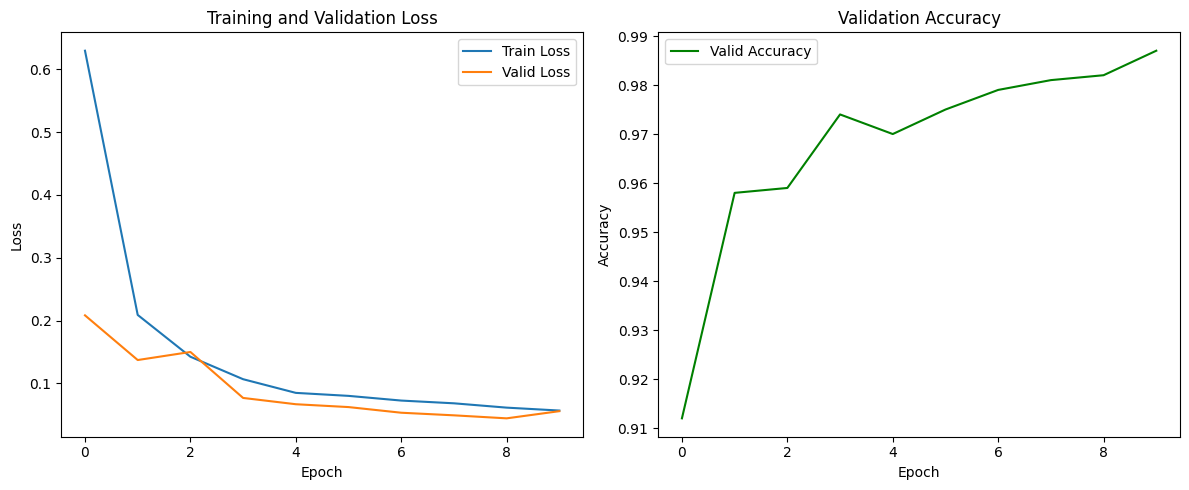

In [ ]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(valid_losses, label='Valid Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(valid_accuracies, label='Valid Accuracy', color='green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.savefig('training_metrics.png')
plt.show()

In [ ]:
model.load_state_dict(torch.load('models/node.pth'))
model.eval()

y_true = []
y_pred = []
test_loss = 0.0
correct = 0
total = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        test_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

test_loss = test_loss / len(test_loader.dataset)
test_accuracy = correct / total

print('\n==============================================')
print('Đánh giá mô hình trên tập test:')
print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_accuracy:.4f}')
print('\nClassification Report:')
print(classification_report(y_true, y_pred))
print('\nConfusion Matrix:')


Đánh giá mô hình trên tập test:
Test Loss: 0.0564
Test Accuracy: 0.9810

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       227
           1       1.00      0.95      0.97       256
           2       0.95      0.99      0.97       250
           3       0.99      1.00      0.99       267

    accuracy                           0.98      1000
   macro avg       0.98      0.98      0.98      1000
weighted avg       0.98      0.98      0.98      1000


Confusion Matrix:


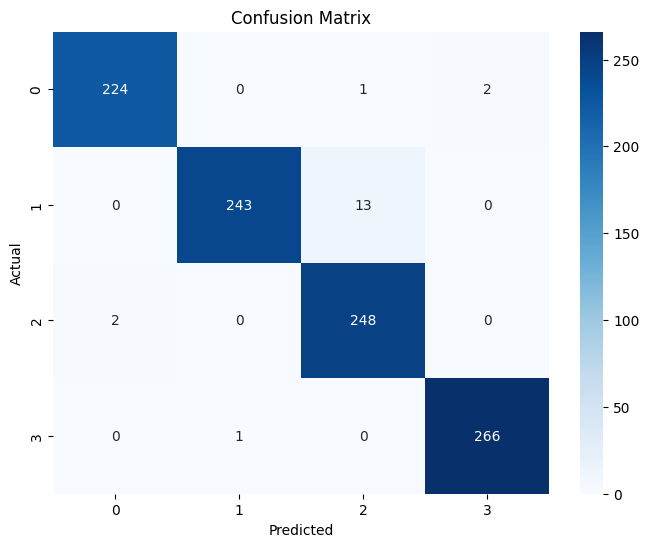

In [ ]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
results = {
    'test_loss': test_loss,
    'test_accuracy': test_accuracy,
    'precision': precision_score(y_true, y_pred, average='weighted'),
    'recall': recall_score(y_true, y_pred, average='weighted'),
    'f1_score': f1_score(y_true, y_pred, average='weighted')
}

print('\nCác chỉ số đánh giá:')
for k, v in results.items():
    print(f'{k}: {v:.4f}')


Các chỉ số đánh giá:
test_loss: 0.0564
test_accuracy: 0.9810
precision: 0.9816
recall: 0.9810
f1_score: 0.9810


## test

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
def save_scaler():
    df = pd.read_csv('csv/merge.csv')

    selected_columns = ['Protocol', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 
                    'Fwd Packets Length Total', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 
                    'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 
                    'Bwd Packet Length Mean', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 
                    'Flow IAT Max', 'Flow IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Min', 
                    'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 
                    'Bwd Header Length', 'Bwd Packets/s', 'Packet Length Max', 'FIN Flag Count', 'SYN Flag Count', 
                    'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count', 'Down/Up Ratio', 
                    'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 
                    'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate', 'Init Fwd Win Bytes', 'Init Bwd Win Bytes', 
                    'Fwd Seg Size Min', 'Active Mean', 'Active Std', 'Active Max', 'Active Min', 'Idle Std', 'Label']

    df = df[selected_columns]
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.fillna(0, inplace=True)
    
    X = df.drop(columns=['Label']).values  # Giả sử cột nhãn là 'Label'
    y = df['Label'].values
    
    if isinstance(y[0], str):
        le = LabelEncoder()
        y = le.fit_transform(y)
        print("\nCác lớp nhãn đã mã hóa:", le.classes_)
    
    scaler = StandardScaler()
    X = scaler.fit_transform(X)
    joblib.dump(scaler, 'test/scaler/node_scaler.pkl')

save_scaler()

def load_and_preprocess_data(file_path):
    df = pd.read_csv(file_path)

    selected_columns = ['Protocol', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 
                    'Fwd Packets Length Total', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 
                    'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 
                    'Bwd Packet Length Mean', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 
                    'Flow IAT Max', 'Flow IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Min', 
                    'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 
                    'Bwd Header Length', 'Bwd Packets/s', 'Packet Length Max', 'FIN Flag Count', 'SYN Flag Count', 
                    'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count', 'Down/Up Ratio', 
                    'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 
                    'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate', 'Init Fwd Win Bytes', 'Init Bwd Win Bytes', 
                    'Fwd Seg Size Min', 'Active Mean', 'Active Std', 'Active Max', 'Active Min', 'Idle Std', 'Label']

    df = df[selected_columns]
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.fillna(0, inplace=True)
    
    X = df.drop(columns=['Label']).values  
    y = df['Label'].values
    
    if isinstance(y[0], str):
        le = LabelEncoder()
        y = le.fit_transform(y)
        print("\nCác lớp nhãn đã mã hóa:", le.classes_)
    
    scaler = joblib.load('test/scaler/node_scaler.pkl')
    X = scaler.fit_transform(X)
    
    return X, y


Các lớp nhãn đã mã hóa: ['BENIGN' 'Group1' 'Group2' 'Syn']


In [ ]:
class ODEFunc(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(ODEFunc, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, input_dim)
        )

    def forward(self, t, x):
        return self.net(x)

class NODEClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, ode_hidden_dim):
        super(NODEClassifier, self).__init__()
        self.ode_func = ODEFunc(input_dim, ode_hidden_dim)
        self.fc = nn.Linear(input_dim, output_dim)
        self.integration_time = torch.tensor([0, 1]).float().to(device)

    def forward(self, x):
        x = odeint(self.ode_func, x, self.integration_time, method='dopri5')[-1]
        return self.fc(x)
    

input_dim =  X.shape[1]  
hidden_dim = 64
ode_hidden_dim = 64
output_dim = 4

model = NODEClassifier(input_dim, hidden_dim, output_dim, ode_hidden_dim).to(device)
model.load_state_dict(torch.load('models/node.pth'))
model.eval()

NODEClassifier(
  (ode_func): ODEFunc(
    (net): Sequential(
      (0): Linear(in_features=49, out_features=64, bias=True)
      (1): Tanh()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): Tanh()
      (4): Linear(in_features=64, out_features=49, bias=True)
    )
  )
  (fc): Linear(in_features=49, out_features=4, bias=True)
)

In [ ]:
file_path = 'test/syn.csv' 
X, y = load_and_preprocess_data(file_path)

# Chuyển sang tensor
X_new_tensor = torch.FloatTensor(X).to(device)
y_new_tensor = torch.LongTensor(y).to(device)

# Dự đoán
model.eval()
with torch.no_grad():
    outputs = model(X_new_tensor)
    _, predicted = torch.max(outputs, 1)
    correct = (predicted == y_new_tensor).sum().item()
    accuracy = correct / len(y_new_tensor)

print(f"Accuracy: {accuracy:.4f}")


Các lớp nhãn đã mã hóa: ['Syn']
Accuracy trên dữ liệu mới: 0.5025
